In [1]:
!pip install grad_cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 41.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad_cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=2acb3adeba2c761c14477c54b2de069d4f7e67d16b2c9daa106a82843e8cb0d0
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad_cam


 Loading Hugging Face ViT model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Using device: CUDA
 Initializing GlassBox-ViT (ScoreCAMExplainer)...
 Loading and resizing test image (Chelsea the cat)...
 Generating Score CAM Feature Visualization...


100%|██████████| 48/48 [00:08<00:00,  5.44it/s]



 Score CAM VISUALIZATION GENERATED SUCCESSFULLY
-> Model Prediction: Egyptian cat (97.55%)


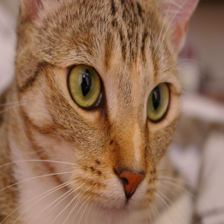

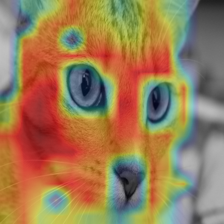

In [3]:
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from skimage import data
from IPython.display import display

from scorecam_explainer import ScoreCamExplainer

# --- MODEL SETUP ---
print(" Loading Hugging Face ViT model...")
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)

# We request the hidden states from the model
model = AutoModelForImageClassification.from_pretrained(
    model_name
)

# The user decides where the model lives
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device.upper()}")
model.to(device)

# Extract class names from the model config
class_names = list(model.config.id2label.values())

# --- INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT (ScoreCAMExplainer)...")
# Explainer: Passes model and processor.
scorecam_explainer = ScoreCamExplainer(
    model=model,
    processor=processor
)

# --- LOAD TEST IMAGE ---
print(" Loading and resizing test image (Chelsea the cat)...")
image_np = data.cat()
# ViT models expect 224x224 images
test_image = Image.fromarray(image_np).convert("RGB").resize((224, 224))

# --- GENERATE EXPLANATION ---
print(" Generating Score CAM Feature Visualization...")

result = scorecam_explainer.generate(pil_image=test_image)

# --- DISPLAY RESULTS  ---
# Extract final metrics
predicted_class = class_names[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n Score CAM VISUALIZATION GENERATED SUCCESSFULLY")
print(f"-> Model Prediction: {predicted_class} ({confidence:.2f}%)")

# Display the image directly in the notebook cell output
display(test_image)
display(result['scorecam_image'])